# Candidate Dataset Investigation: Rice Pest and Diseases
**Project:** AI-Based Crop Health Monitoring, Disease Detection and Agricultural Decision Support System  
**Module 1:** Rice Crop Disease/Pest Risk Prediction using Agro-Meteorological Data  
**Candidate Dataset:** [Rice - Pest and Diseases (Kaggle)](https://www.kaggle.com/datasets/zsinghrahulk/rice-pest-and-diseases)  
**Notebook:** `ml-service/notebooks/01_dataset_investigation.ipynb`  

---

> ⚠️ **CRITICAL INVESTIGATION NOTICE**  
> This dataset is an initial **CANDIDATE** dataset. It has not yet been approved as the final dataset for Module 1.  
> **No machine learning models are trained in this notebook**, and no production pipelines or endpoints are created.  
> The sole purpose of this notebook is to execute an exhaustive exploratory data analysis (EDA), audit data quality, examine potential targets, and assess whether this dataset is technically and agronomically suitable for weather-based rice pest/disease risk prediction.


In [1]:
import os
import sys
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Ensure figures output directory exists
figures_dir = Path('../experiments/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Figures directory: {figures_dir.resolve()}")


Pandas version: 3.0.5
Numpy version: 2.5.3
Seaborn version: 0.13.2
Figures directory: C:\Users\akasi\OneDrive\Desktop\adventurous-hawking\ml-service\experiments\figures


## SECTION 1 — Dataset Loading
In this section, we locate and load the candidate dataset from `ml-service/data/raw/` without altering or cleaning the original file. We inspect the file metadata, shape, column names, sample records, and preliminary data types.


In [2]:
# Check raw directory contents
raw_dir = Path('../data/raw')
if not raw_dir.exists():
    raw_dir = Path('ml-service/data/raw')

raw_files = [f.name for f in raw_dir.glob('*') if f.is_file()]
print(f"Files found in raw directory ({raw_dir}):")
for f in raw_files:
    size_kb = (raw_dir / f).stat().st_size / 1024
    print(f"  - {f} ({size_kb:.2f} KB)")

# Load dataset
dataset_path = raw_dir / 'RICE.csv'
df = pd.read_csv(dataset_path)

print(f"\nDataset Loaded Successfully from: {dataset_path}")
print(f"Total Rows (Records): {df.shape[0]:,}")
print(f"Total Columns (Features): {df.shape[1]}")

print("\nFirst 10 Rows:")
display(df.head(10))

print("\nColumn Names and Data Types:")
dtypes_df = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum(),
    'Unique Values': df.nunique()
}).reset_index(drop=True)
display(dtypes_df)


Files found in raw directory (..\data\raw):
  - .gitkeep (0.00 KB)
  - RICE.csv (1634.86 KB)

Dataset Loaded Successfully from: ..\data\raw\RICE.csv
Total Rows (Records): 19,404
Total Columns (Features): 14

First 10 Rows:


,Observation Year,Standard Week,Pest Value,Collection Type,MaxT,MinT,RH1(%),RH2(%),RF(mm),WS(kmph),SSH(hrs),EVP(mm),PEST NAME,Location
0,2003,1,0.0,Number/hill,27.9,14.8,94.7,51.3,0.0,3.1,8.7,2.7,Brownplanthopper,Cuttack
1,2003,2,0.0,Number/hill,27.2,15.0,93.9,53.1,0.0,2.1,8.7,2.4,Brownplanthopper,Cuttack
2,2003,3,0.0,Number/hill,28.7,18.3,94.1,56.7,0.6,4.8,6.7,2.8,Brownplanthopper,Cuttack
3,2003,4,0.0,Number/hill,25.3,16.4,90.9,57.4,0.3,6.5,5.3,3.0,Brownplanthopper,Cuttack
4,2003,5,0.0,Number/hill,28.8,18.7,95.7,55.0,0.0,5.2,6.3,2.8,Brownplanthopper,Cuttack
5,2003,6,0.0,Number/hill,27.1,17.2,94.9,53.3,4.4,3.5,6.9,2.9,Brownplanthopper,Cuttack
6,2003,7,0.0,Number/hill,30.7,16.0,93.9,33.0,0.0,2.6,10.2,4.0,Brownplanthopper,Cuttack
7,2003,8,0.0,Number/hill,30.4,21.4,95.3,56.9,15.4,5.1,6.4,3.4,Brownplanthopper,Cuttack
8,2003,9,0.0,Number/hill,31.1,22.3,92.6,56.7,17.5,6.0,6.5,4.2,Brownplanthopper,Cuttack
9,2003,10,0.0,Number/hill,31.1,21.5,95.3,54.7,0.0,3.5,7.5,4.2,Brownplanthopper,Cuttack



Column Names and Data Types:


,Column Name,Data Type,Non-Null Count,Null Count,Unique Values
0,Observation Year,int64,19404,0,48
1,Standard Week,int64,19404,0,52
2,Pest Value,float64,19404,0,2564
3,Collection Type,str,19404,0,5
4,MaxT,float64,19404,0,331
5,MinT,float64,19404,0,281
6,RH1(%),float64,19404,0,544
7,RH2(%),float64,19404,0,637
8,RF(mm),float64,19404,0,1099
9,WS(kmph),float64,19404,0,201


## SECTION 2 — Dataset Description
Here we analyze every column in the dataset to describe what agricultural or meteorological parameter it represents, its physical unit, and its operational interpretation.

### Domain Glossary of Columns
| Column Name | Data Type | Physical / Domain Meaning | Unit | Verification Status |
| :--- | :--- | :--- | :--- | :--- |
| **`Observation Year`** | Integer | Calendar year of field surveillance observation (1959–2011) | Year | Verified |
| **`Standard Week`** | Integer | Standard Meteorological Week (SMW 1–52) across annual crop seasons | Week (1–52) | Verified |
| **`Pest Value`** | Float | Quantitative observation metric (trap count, insects/hill, or disease %) | Heterogeneous | Requires Segmentation |
| **`Collection Type`** | String | Sampling methodology / surveillance protocol | Categorical (5 types) | Verified |
| **`MaxT`** | Float | Weekly mean maximum temperature | °C | Verified (Outliers noted) |
| **`MinT`** | Float | Weekly mean minimum temperature | °C | Verified |
| **`RH1(%)`** | Float | Morning relative humidity (recorded ~07:00–08:30 IST) | % | Verified |
| **`RH2(%)`** | Float | Evening/afternoon relative humidity (recorded ~14:00 IST) | % | Verified |
| **`RF(mm)`** | Float | Cumulative weekly rainfall | mm | Verified |
| **`WS(kmph)`** | Float | Mean wind speed | km/h | Verified |
| **`SSH(hrs)`** | Float | Sunshine hours (mean daily bright sunshine duration) | hours/day | Requires Verification (Anomalies) |
| **`EVP(mm)`** | Float | Evaporation rate (pan evaporimeter) | mm | Verified |
| **`PEST NAME`** | String | Target rice pest or disease entity (9 insect pests, 2 fungal diseases) | Categorical (11 classes) | Verified |
| **`Location`** | String | ICAR / SAU Agricultural Research Station in India | Categorical (6 stations) | Verified |


In [3]:
print("=== DataFrame Info ===")
df.info()

print("\n=== Statistical Summary of Numerical Features ===")
display(df.describe().T.round(2))

print("\n=== Value Counts for Categorical Features ===")
for cat_col in ['PEST NAME', 'Location', 'Collection Type']:
    print(f"\n--- Feature: {cat_col} (Unique: {df[cat_col].nunique()}) ---")
    counts = df[cat_col].value_counts()
    percentages = df[cat_col].value_counts(normalize=True) * 100
    cat_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    display(cat_summary)


=== DataFrame Info ===
<class 'pandas.DataFrame'>
RangeIndex: 19404 entries, 0 to 19403
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Observation Year  19404 non-null  int64  
 1   Standard Week     19404 non-null  int64  
 2   Pest Value        19404 non-null  float64
 3   Collection Type   19404 non-null  str    
 4   MaxT              19404 non-null  float64
 5   MinT              19404 non-null  float64
 6   RH1(%)            19404 non-null  float64
 7   RH2(%)            19404 non-null  float64
 8   RF(mm)            19404 non-null  float64
 9   WS(kmph)          19404 non-null  float64
 10  SSH(hrs)          19404 non-null  float64
 11  EVP(mm)           19404 non-null  float64
 12  PEST NAME         19404 non-null  str    
 13  Location          19404 non-null  str    
dtypes: float64(9), int64(2), str(3)
memory usage: 2.1 MB

=== Statistical Summary of Numerical Features ===


,count,mean,std,min,25%,50%,75%,max
Observation Year,19404.0,2000.02,9.83,1959.0,1996.0,2001.0,2007.00,2011.0
Standard Week,19404.0,26.47,15.02,1.0,13.0,26.0,39.00,52.0
Pest Value,19404.0,807.94,5290.18,0.0,0.0,3.0,92.00,311169.0
MaxT,19404.0,31.17,4.90,10.9,28.8,30.9,33.42,71.6
MinT,19404.0,20.40,5.39,0.8,17.5,22.0,24.40,30.9
RH1(%),19404.0,82.19,13.85,9.3,79.1,87.3,91.00,100.0
RH2(%),19404.0,53.73,18.95,6.7,38.0,56.6,69.00,95.1
RF(mm),19404.0,19.41,39.16,0.0,0.0,0.0,21.40,444.4
WS(kmph),19404.0,4.50,3.19,0.0,2.3,3.7,5.90,27.6
SSH(hrs),19404.0,6.86,4.18,0.0,4.9,7.3,8.90,127.1



=== Value Counts for Categorical Features ===

--- Feature: PEST NAME (Unique: 11) ---


,Count,Percentage (%)
PEST NAME,,
Yellowstemborer,4333,22.33
Gallmidge,3016,15.54
Greenleafhopper,2287,11.79
LeafBlast,2090,10.77
Brownplanthopper,1958,10.09
LeafFolder,1716,8.84
Whitebackedplanthopper,1248,6.43
Miridbug,1144,5.90
Caseworm,936,4.82



--- Feature: Location (Unique: 6) ---


,Count,Percentage (%)
Location,,
Maruteru,7053,36.35
Rajendranagar,5539,28.55
Raipur,2132,10.99
Ludhiana,1976,10.18
Cuttack,1456,7.50
Palampur,1248,6.43



--- Feature: Collection Type (Unique: 5) ---


,Count,Percentage (%)
Collection Type,,
Number/Light trap,16430,84.67
Percentage,2298,11.84
Number/Pheromone trap,520,2.68
Percent Damage,104,0.54
Number/hill,52,0.27


## SECTION 3 — Missing Values
We evaluate missing values explicitly across all columns using both absolute null counts and percentages. We also inspect for possible implicit missing values (e.g. whitespace or sentinel values like -999).


In [4]:
# Explicit null check
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_pct.round(2)
}).reset_index(drop=True)

print("=== Missing Value Audit ===")
display(missing_df)

# Check for whitespace-only strings in object columns
for str_col in ['Collection Type', 'PEST NAME', 'Location']:
    empty_strings = (df[str_col].astype(str).str.strip() == '').sum()
    print(f"Empty/whitespace strings in '{str_col}': {empty_strings}")

# Check for standard placeholder negative values (-999, -1, 9999)
for num_col in ['MaxT', 'MinT', 'RH1(%)', 'RH2(%)', 'RF(mm)', 'WS(kmph)', 'SSH(hrs)', 'EVP(mm)', 'Pest Value']:
    neg_count = (df[num_col] < 0).sum()
    sentinel_999 = (df[num_col] == 999).sum() + (df[num_col] == 9999).sum()
    print(f"Negative values in '{num_col}': {neg_count} | Sentinel (999/9999): {sentinel_999}")


=== Missing Value Audit ===


,Column,Missing Count,Missing Percentage (%)
0,Observation Year,0,0.0
1,Standard Week,0,0.0
2,Pest Value,0,0.0
3,Collection Type,0,0.0
4,MaxT,0,0.0
5,MinT,0,0.0
6,RH1(%),0,0.0
7,RH2(%),0,0.0
8,RF(mm),0,0.0
9,WS(kmph),0,0.0


Empty/whitespace strings in 'Collection Type': 0
Empty/whitespace strings in 'PEST NAME': 0
Empty/whitespace strings in 'Location': 0
Negative values in 'MaxT': 0 | Sentinel (999/9999): 0
Negative values in 'MinT': 0 | Sentinel (999/9999): 0
Negative values in 'RH1(%)': 0 | Sentinel (999/9999): 0
Negative values in 'RH2(%)': 0 | Sentinel (999/9999): 0
Negative values in 'RF(mm)': 0 | Sentinel (999/9999): 0
Negative values in 'WS(kmph)': 0 | Sentinel (999/9999): 0
Negative values in 'SSH(hrs)': 0 | Sentinel (999/9999): 0
Negative values in 'EVP(mm)': 0 | Sentinel (999/9999): 0
Negative values in 'Pest Value': 0 | Sentinel (999/9999): 0


## SECTION 4 — Duplicates
We investigate exact duplicate rows across all 14 columns, as well as composite key duplicates across `(Observation Year, Standard Week, Location, PEST NAME)`.


In [5]:
# Exact duplicate rows
exact_duplicates = df.duplicated().sum()
exact_dup_pct = (exact_duplicates / len(df)) * 100

print(f"Number of exact duplicate rows across all 14 columns: {exact_duplicates}")
print(f"Exact duplicate percentage: {exact_dup_pct:.2f}%")

# Check composite key uniqueness: (Year, Week, Location, Pest Name)
key_cols = ['Observation Year', 'Standard Week', 'Location', 'PEST NAME']
key_duplicates = df.duplicated(subset=key_cols, keep=False).sum()
key_dup_pct = (key_duplicates / len(df)) * 100

print(f"Rows with non-unique composite key (Year, Week, Location, Pest): {key_duplicates} ({key_dup_pct:.2f}%)")

if key_duplicates > 0:
    print("\nSample rows sharing composite keys:")
    display(df[df.duplicated(subset=key_cols, keep=False)].sort_values(by=key_cols).head(6))


Number of exact duplicate rows across all 14 columns: 0
Exact duplicate percentage: 0.00%
Rows with non-unique composite key (Year, Week, Location, Pest): 446 (2.30%)

Sample rows sharing composite keys:


,Observation Year,Standard Week,Pest Value,Collection Type,MaxT,MinT,RH1(%),RH2(%),RF(mm),WS(kmph),SSH(hrs),EVP(mm),PEST NAME,Location
2756,1995,1,0.0,Number/Light trap,19.2,3.5,94.7,48.9,1.0,1.6,7.1,1.3,Yellowstemborer,Ludhiana
3224,1995,1,0.0,Number/Pheromone trap,19.2,3.5,94.7,48.9,1.0,1.6,7.1,1.3,Yellowstemborer,Ludhiana
2757,1995,2,0.0,Number/Light trap,15.4,5.5,96.6,75.0,44.2,4.0,5.1,1.4,Yellowstemborer,Ludhiana
3225,1995,2,0.0,Number/Pheromone trap,15.4,5.5,96.6,75.0,44.2,4.0,5.1,1.4,Yellowstemborer,Ludhiana
2758,1995,3,0.0,Number/Light trap,16.3,6.6,96.3,62.4,4.4,4.1,7.3,1.3,Yellowstemborer,Ludhiana
3226,1995,3,0.0,Number/Pheromone trap,16.3,6.6,96.3,62.4,4.4,4.1,7.3,1.3,Yellowstemborer,Ludhiana


## SECTION 5 — Target Investigation
In this section, we analyze potential candidates for the machine learning target column:
1. **`Pest Value` (Continuous Target):** Quantitative population/severity count.
2. **`PEST NAME` (Categorical Multi-class Target):** Predict which pest species is present given weather conditions.
3. **Derived Binary Risk Target (`Pest Value > 0`):** Outbreak / Infestation occurrence (Presence vs. Absence).
4. **Derived Ordinal Risk Classes (Severity Tiers):** Low, Moderate, High risk categories.

> ⚠️ **Key Finding on `Pest Value` Heterogeneity:**  
> As discovered below, `Pest Value` has radically different meanings and units depending on `Collection Type` and `PEST NAME`. For fungal diseases (`LeafBlast`, `NeckBlast`), `Pest Value` is a **percentage** (0–87.2%). For insect pests, `Pest Value` is a **trap count** (often thousands of insects per trap per week, reaching 311,169). Therefore, `Pest Value` cannot be modeled as a single global regression target across the entire dataset without pest-specific normalization or stratification.


In [6]:
print("=== TARGET CANDIDATE 1: 'PEST NAME' ===")
pest_counts = df['PEST NAME'].value_counts()
pest_pct = df['PEST NAME'].value_counts(normalize=True) * 100
pest_target_df = pd.DataFrame({
    'Unique Class': pest_counts.index,
    'Frequency': pest_counts.values,
    'Percentage (%)': pest_pct.values.round(2)
})
display(pest_target_df)

print("\n=== TARGET CANDIDATE 2: 'Pest Value' (Zero-Inflation & Heterogeneity Audit) ===")
overall_zeros = (df['Pest Value'] == 0).sum()
print(f"Overall Zero Count: {overall_zeros:,} / {len(df):,} ({overall_zeros/len(df)*100:.2f}%)")

pest_value_stats = []
for pest in sorted(df['PEST NAME'].unique()):
    sub = df[df['PEST NAME'] == pest]
    zeros = (sub['Pest Value'] == 0).sum()
    col_types = ", ".join(sub['Collection Type'].unique())
    pest_value_stats.append({
        'Pest / Disease': pest,
        'Collection Types': col_types,
        'Count': len(sub),
        'Zeroes': zeros,
        'Zero (%)': round(zeros / len(sub) * 100, 2),
        'Min': sub['Pest Value'].min(),
        'Median': sub['Pest Value'].median(),
        'Mean': round(sub['Pest Value'].mean(), 2),
        'Max': sub['Pest Value'].max()
    })
display(pd.DataFrame(pest_value_stats))

print("\n=== TARGET CANDIDATE 3: Binary Infestation Risk (Pest Value > 0) ===")
df['Risk_Binary'] = (df['Pest Value'] > 0).astype(int)
binary_counts = df['Risk_Binary'].value_counts()
binary_pct = df['Risk_Binary'].value_counts(normalize=True) * 100
display(pd.DataFrame({
    'Binary Class': ['0 (No Infestation / Negligible)', '1 (Active Infestation / Present)'],
    'Frequency': binary_counts.values,
    'Percentage (%)': binary_pct.values.round(2)
}))


=== TARGET CANDIDATE 1: 'PEST NAME' ===


,Unique Class,Frequency,Percentage (%)
0,Yellowstemborer,4333,22.33
1,Gallmidge,3016,15.54
2,Greenleafhopper,2287,11.79
3,LeafBlast,2090,10.77
4,Brownplanthopper,1958,10.09
5,LeafFolder,1716,8.84
6,Whitebackedplanthopper,1248,6.43
7,Miridbug,1144,5.90
8,Caseworm,936,4.82
9,ZigZagleafhopper,468,2.41



=== TARGET CANDIDATE 2: 'Pest Value' (Zero-Inflation & Heterogeneity Audit) ===
Overall Zero Count: 8,670 / 19,404 (44.68%)


,Pest / Disease,Collection Types,Count,Zeroes,Zero (%),Min,Median,Mean,Max
0,Brownplanthopper,"Number/hill, Number/Light trap",1958,785,40.09,0.0,79.5,2648.92,123391.00
1,Caseworm,Number/Light trap,936,457,48.82,0.0,1.0,13.36,649.00
2,Gallmidge,"Number/Light trap, Percent Damage",3016,1863,61.77,0.0,0.0,277.31,163162.00
3,Greenleafhopper,Number/Light trap,2287,823,35.99,0.0,32.0,1999.95,311169.00
4,LeafBlast,Percentage,2090,1661,79.47,0.0,0.0,4.24,87.20
5,LeafFolder,Number/Light trap,1716,625,36.42,0.0,4.0,33.99,1520.00
6,Miridbug,Number/Light trap,1144,268,23.43,0.0,40.0,1149.46,82360.00
7,NeckBlast,Percentage,208,184,88.46,0.0,0.0,0.65,29.12
8,Whitebackedplanthopper,Number/Light trap,1248,458,36.70,0.0,11.0,984.63,266642.00
9,Yellowstemborer,"Number/Light trap, Number/Pheromone trap",4333,1531,35.33,0.0,11.0,438.19,51542.00



=== TARGET CANDIDATE 3: Binary Infestation Risk (Pest Value > 0) ===


,Binary Class,Frequency,Percentage (%)
0,0 (No Infestation / Negligible),10734,55.32
1,1 (Active Infestation / Present),8670,44.68


## SECTION 6 — Data Distribution
We visualize the empirical distributions of:
1. Numerical weather variables (`MaxT`, `MinT`, `RH1`, `RH2`, `RF`, `WS`, `SSH`, `EVP`)
2. Target candidates (`Pest Value` overall and log-transformed, class balance for binary occurrence)
3. Key categorical features (`PEST NAME`, `Location`, `Collection Type`)


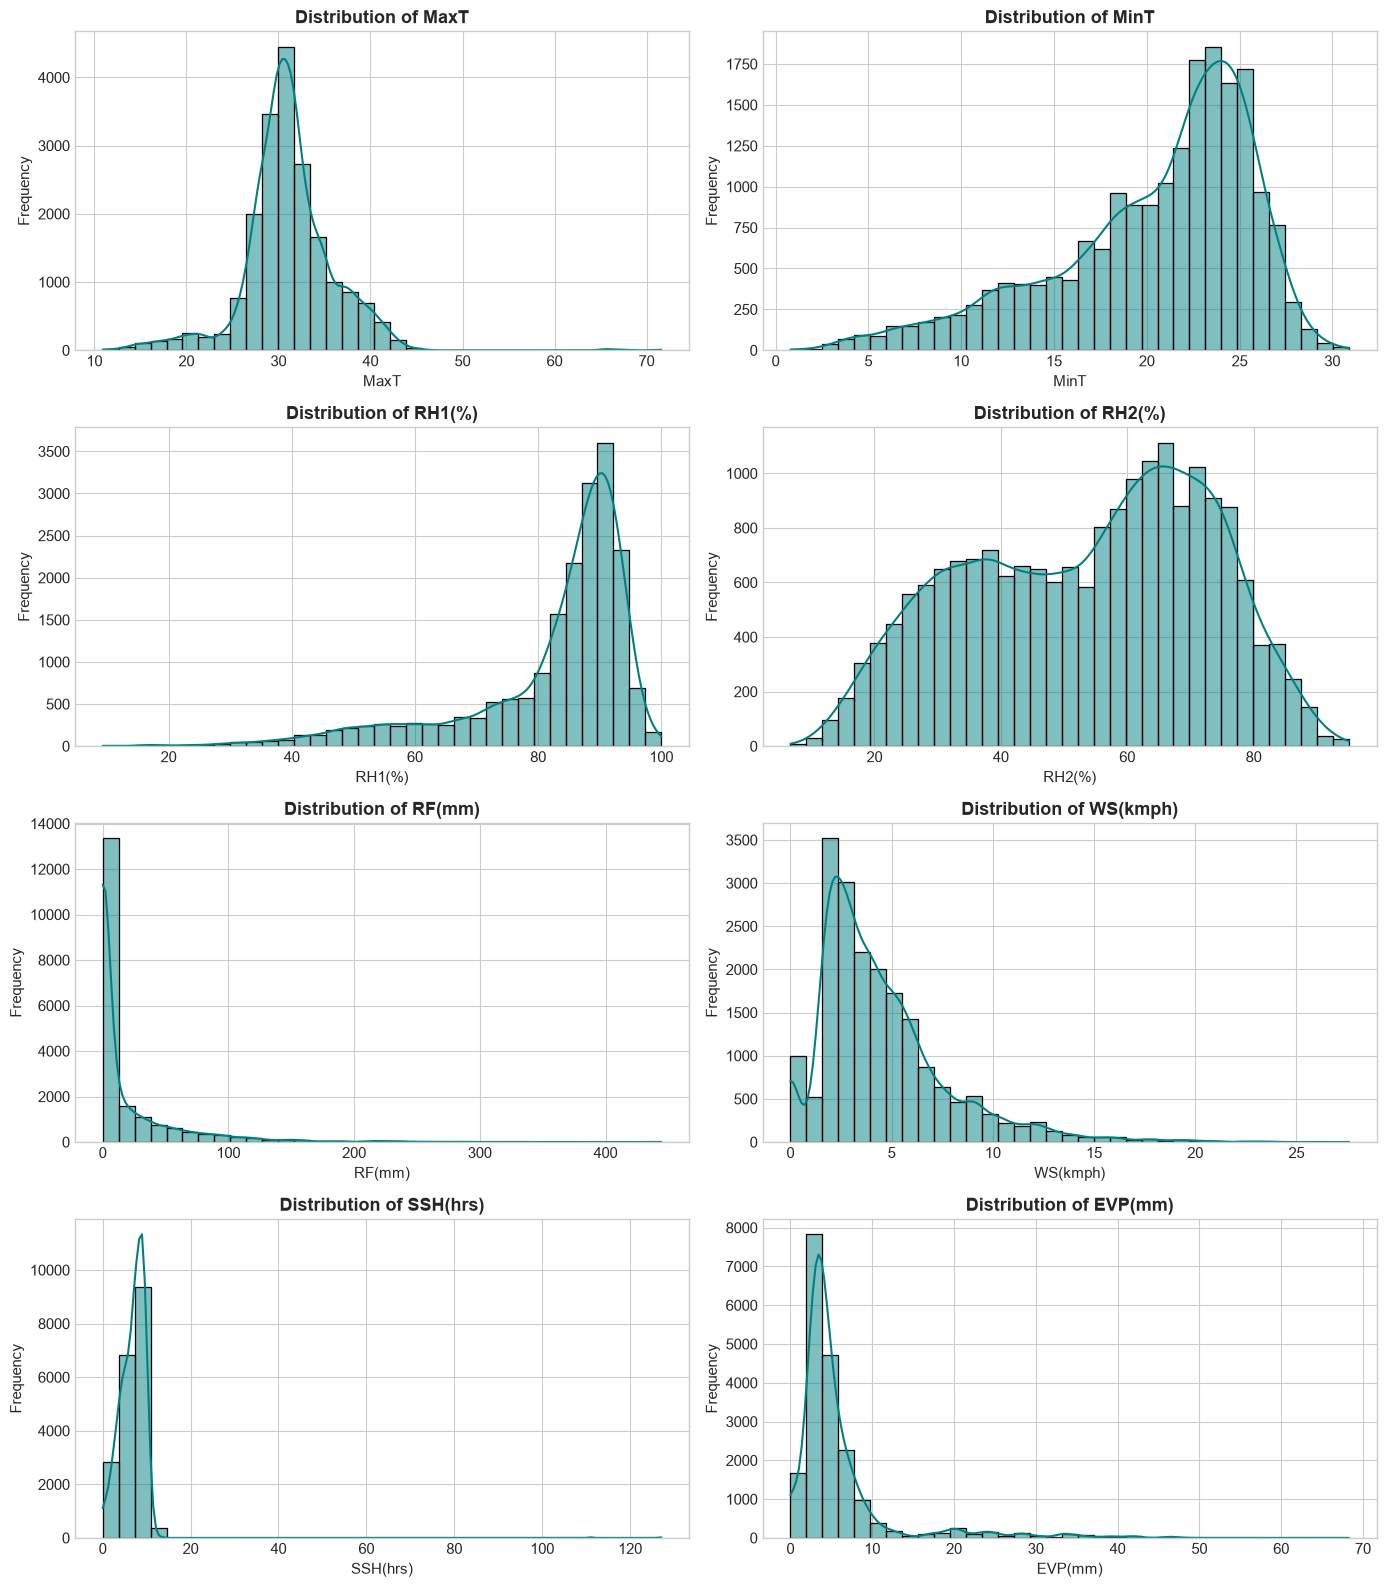

Saved weather distributions to: ..\experiments\figures\01_weather_distributions.png


In [7]:
# 1. Weather Feature Distributions
weather_features = ['MaxT', 'MinT', 'RH1(%)', 'RH2(%)', 'RF(mm)', 'WS(kmph)', 'SSH(hrs)', 'EVP(mm)']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(weather_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=35)
    axes[i].set_title(f"Distribution of {col}", fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
weather_dist_path = figures_dir / '01_weather_distributions.png'
plt.savefig(weather_dist_path, dpi=200)
plt.show()
print(f"Saved weather distributions to: {weather_dist_path}")


C:\Users\akasi\AppData\Local\Temp\ipykernel_14692\1081640184.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='PEST NAME', order=pest_order, ax=axes[0], palette='viridis')
C:\Users\akasi\AppData\Local\Temp\ipykernel_14692\1081640184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Location', order=loc_order, ax=axes[1], palette='crest')


C:\Users\akasi\AppData\Local\Temp\ipykernel_14692\1081640184.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Collection Type', order=coll_order, ax=axes[2], palette='magma')


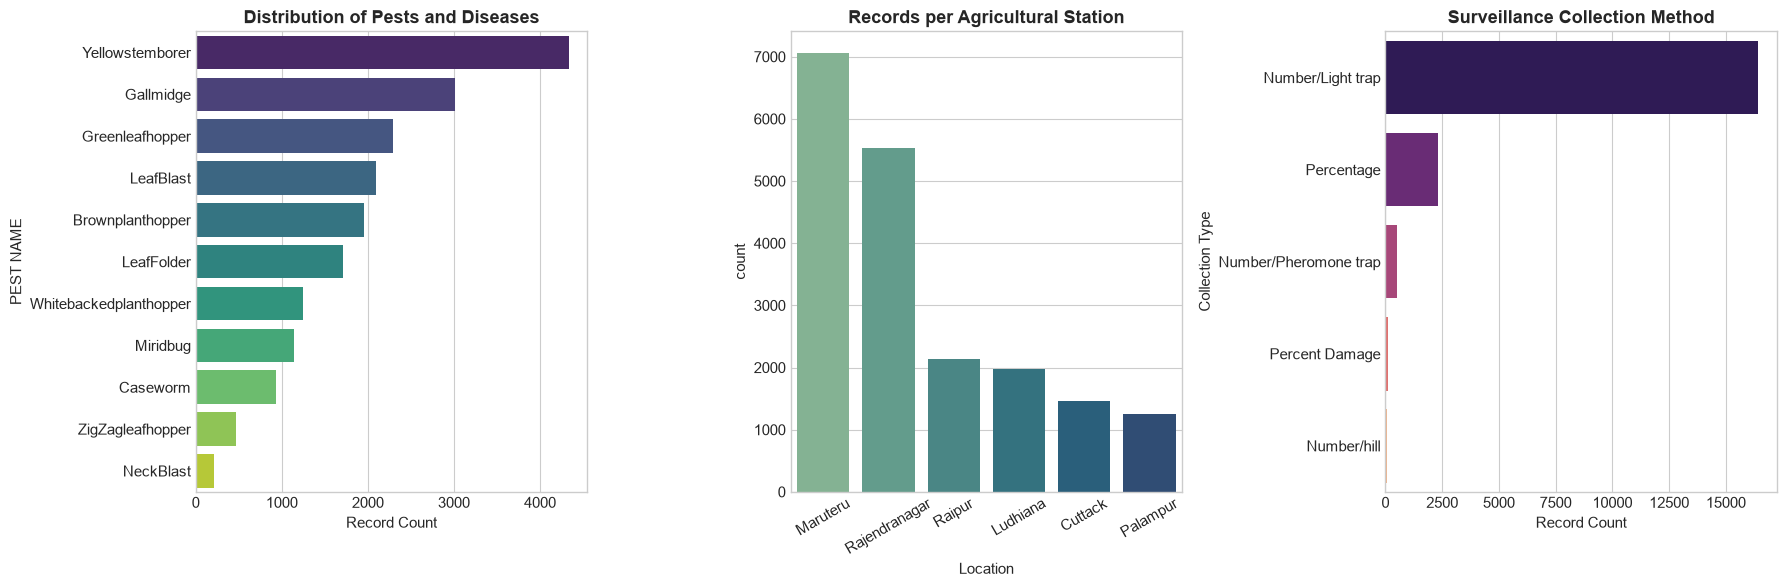

Saved categorical distributions to: ..\experiments\figures\02_categorical_distributions.png


In [8]:
# 2. Categorical Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PEST NAME distribution
pest_order = df['PEST NAME'].value_counts().index
sns.countplot(data=df, y='PEST NAME', order=pest_order, ax=axes[0], palette='viridis')
axes[0].set_title("Distribution of Pests and Diseases", fontweight='bold')
axes[0].set_xlabel("Record Count")

# Location distribution
loc_order = df['Location'].value_counts().index
sns.countplot(data=df, x='Location', order=loc_order, ax=axes[1], palette='crest')
axes[1].set_title("Records per Agricultural Station", fontweight='bold')
axes[1].set_xlabel("Location")
axes[1].tick_params(axis='x', rotation=30)

# Collection Type distribution
coll_order = df['Collection Type'].value_counts().index
sns.countplot(data=df, y='Collection Type', order=coll_order, ax=axes[2], palette='magma')
axes[2].set_title("Surveillance Collection Method", fontweight='bold')
axes[2].set_xlabel("Record Count")

plt.tight_layout()
cat_dist_path = figures_dir / '02_categorical_distributions.png'
plt.savefig(cat_dist_path, dpi=200)
plt.show()
print(f"Saved categorical distributions to: {cat_dist_path}")


C:\Users\akasi\AppData\Local\Temp\ipykernel_14692\2974432978.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Zero (Absence)', 'Positive (Presence)'],


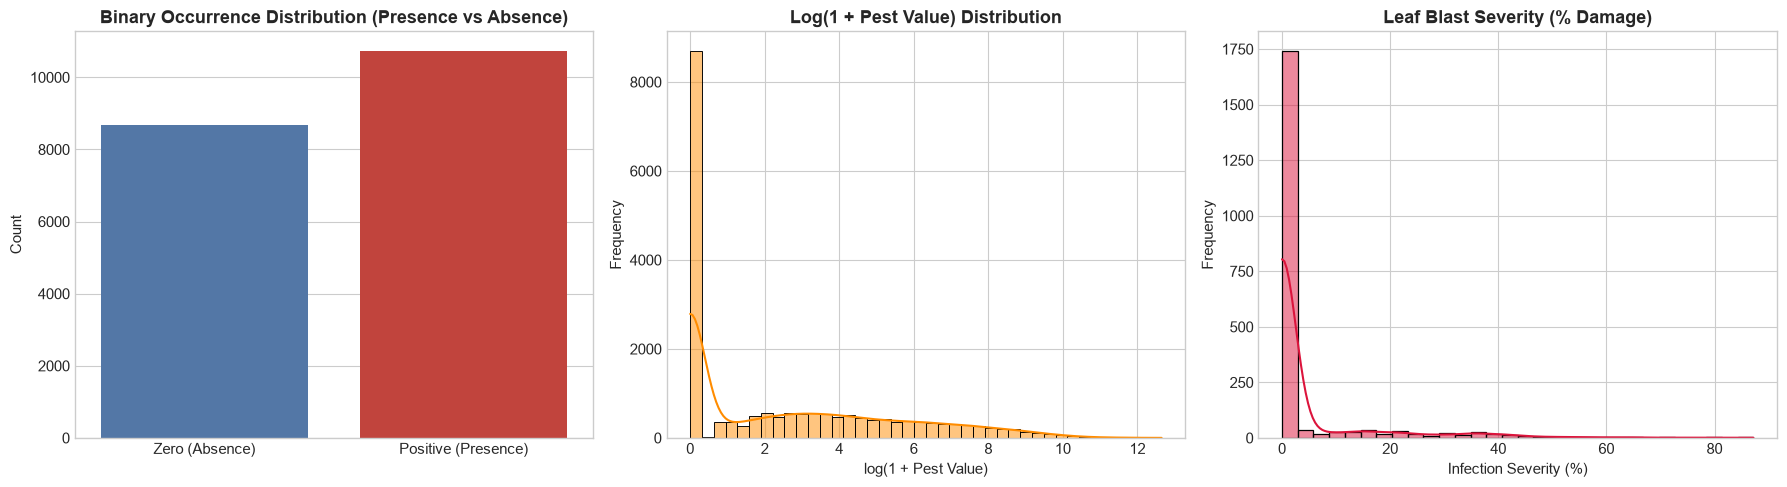

Saved target distributions to: ..\experiments\figures\03_target_distributions.png


In [9]:
# 3. Target Distribution & Severe Skewness
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Binary Presence/Absence
sns.barplot(x=['Zero (Absence)', 'Positive (Presence)'], 
            y=[(df['Pest Value'] == 0).sum(), (df['Pest Value'] > 0).sum()], 
            ax=axes[0], palette=['#4575b4', '#d73027'])
axes[0].set_title("Binary Occurrence Distribution (Presence vs Absence)", fontweight='bold')
axes[0].set_ylabel("Count")

# Log1p transformed Pest Value
sns.histplot(np.log1p(df['Pest Value']), bins=40, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title("Log(1 + Pest Value) Distribution", fontweight='bold')
axes[1].set_xlabel("log(1 + Pest Value)")
axes[1].set_ylabel("Frequency")

# LeafBlast severity distribution
lb_vals = df[df['PEST NAME'] == 'LeafBlast']['Pest Value']
sns.histplot(lb_vals, bins=30, kde=True, ax=axes[2], color='crimson')
axes[2].set_title("Leaf Blast Severity (% Damage)", fontweight='bold')
axes[2].set_xlabel("Infection Severity (%)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
target_dist_path = figures_dir / '03_target_distributions.png'
plt.savefig(target_dist_path, dpi=200)
plt.show()
print(f"Saved target distributions to: {target_dist_path}")


## SECTION 7 — Correlation Analysis
We analyze linear and monotonic relationships among the numerical weather features, and between weather features and `Pest Value`.

> ⚠️ **Critical Methodological Caution:**  
> 1. **Correlation is NOT causation.** A positive correlation between humidity and pest abundance does not imply that humidity alone produces insects; biological development requires pest inoculums and host vulnerability.  
> 2. **Global correlation across all pests is diluted and misleading.** Because different insect species and fungal pathogens have contrasting environmental preferences (e.g. wet cloudy weather favors Leaf Blast, whereas certain stem borers tolerate drier warmer periods), aggregating all species into one `Pest Value` variable obscures species-specific ecological signals.


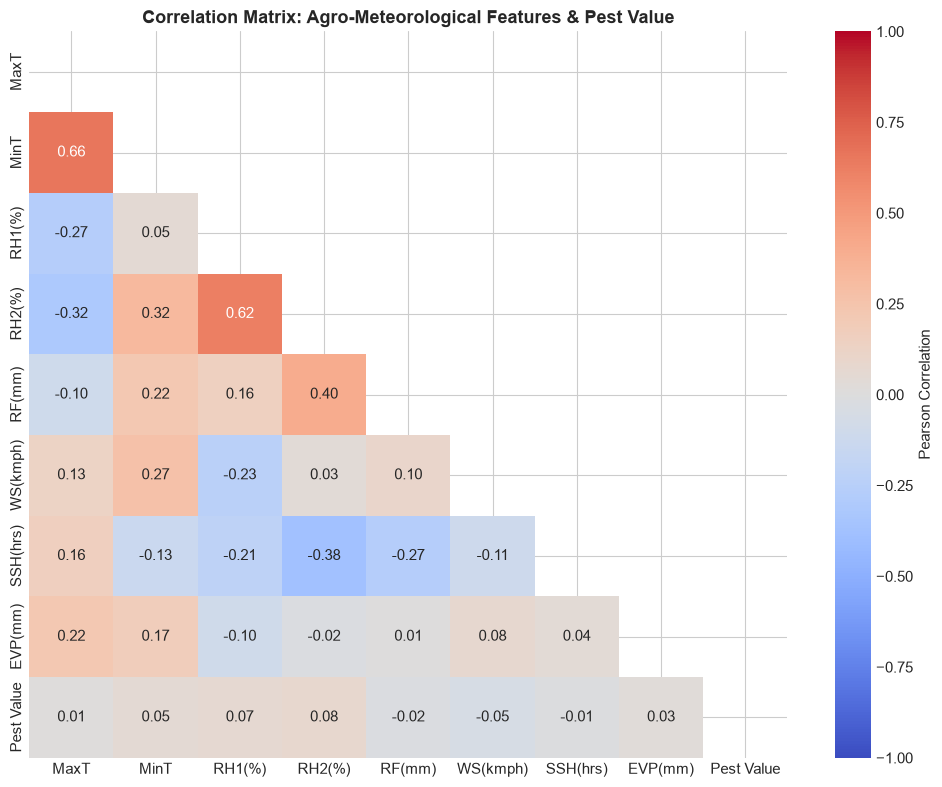

Saved correlation heatmap to: ..\experiments\figures\04_correlation_heatmap.png
=== Pearson Correlation with Pest Value (Global vs Pest-Specific) ===


,Global Pest Value Corr,LeafBlast Corr (Disease),Yellowstemborer Corr (Pest)
MaxT,0.011,0.022,0.041
MinT,0.052,0.186,0.072
RH1(%),0.067,0.303,0.056
RH2(%),0.083,0.346,0.075
RF(mm),-0.016,0.197,-0.048
WS(kmph),-0.048,-0.019,-0.093
SSH(hrs),-0.012,-0.216,0.025
EVP(mm),0.026,-0.057,0.222


In [10]:
# Correlation among weather variables
num_cols = weather_features + ['Pest Value']
weather_corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(weather_corr, dtype=bool))
sns.heatmap(weather_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, cbar_kws={'label': 'Pearson Correlation'})
plt.title("Correlation Matrix: Agro-Meteorological Features & Pest Value", fontweight='bold')
plt.tight_layout()
corr_path = figures_dir / '04_correlation_heatmap.png'
plt.savefig(corr_path, dpi=200)
plt.show()
print(f"Saved correlation heatmap to: {corr_path}")

print("=== Pearson Correlation with Pest Value (Global vs Pest-Specific) ===")
global_corr = df[weather_features + ['Pest Value']].corr()['Pest Value'].drop('Pest Value')

# Specific disease: LeafBlast
lb_corr = df[df['PEST NAME'] == 'LeafBlast'][weather_features + ['Pest Value']].corr()['Pest Value'].drop('Pest Value')

# Specific pest: Yellowstemborer
ysb_corr = df[df['PEST NAME'] == 'Yellowstemborer'][weather_features + ['Pest Value']].corr()['Pest Value'].drop('Pest Value')

corr_comparison = pd.DataFrame({
    'Global Pest Value Corr': global_corr.round(3),
    'LeafBlast Corr (Disease)': lb_corr.round(3),
    'Yellowstemborer Corr (Pest)': ysb_corr.round(3)
})
display(corr_comparison)


## SECTION 8 — Outlier Investigation
We audit the numerical features using the Interquartile Range (IQR) rule ($[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$). We distinguish between natural meteorological extremes (e.g., monsoon rainfall) and data entry errors or unit anomalies.


,Feature,Min,Q1,Median,Q3,Max,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Pct (%)
0,MaxT,10.9,28.8,30.9,33.42,71.6,4.62,21.86,40.36,1431,7.37
1,MinT,0.8,17.5,22.0,24.40,30.9,6.90,7.15,34.75,512,2.64
2,RH1(%),9.3,79.1,87.3,91.00,100.0,11.90,61.25,108.85,2022,10.42
3,RH2(%),6.7,38.0,56.6,69.00,95.1,31.00,-8.50,115.50,0,0.00
4,RF(mm),0.0,0.0,0.0,21.40,444.4,21.40,-32.10,53.50,2475,12.76
5,WS(kmph),0.0,2.3,3.7,5.90,27.6,3.60,-3.10,11.30,849,4.38
6,SSH(hrs),0.0,4.9,7.3,8.90,127.1,4.00,-1.10,14.90,16,0.08
7,EVP(mm),0.0,2.9,4.0,6.00,68.3,3.10,-1.75,10.65,1718,8.85


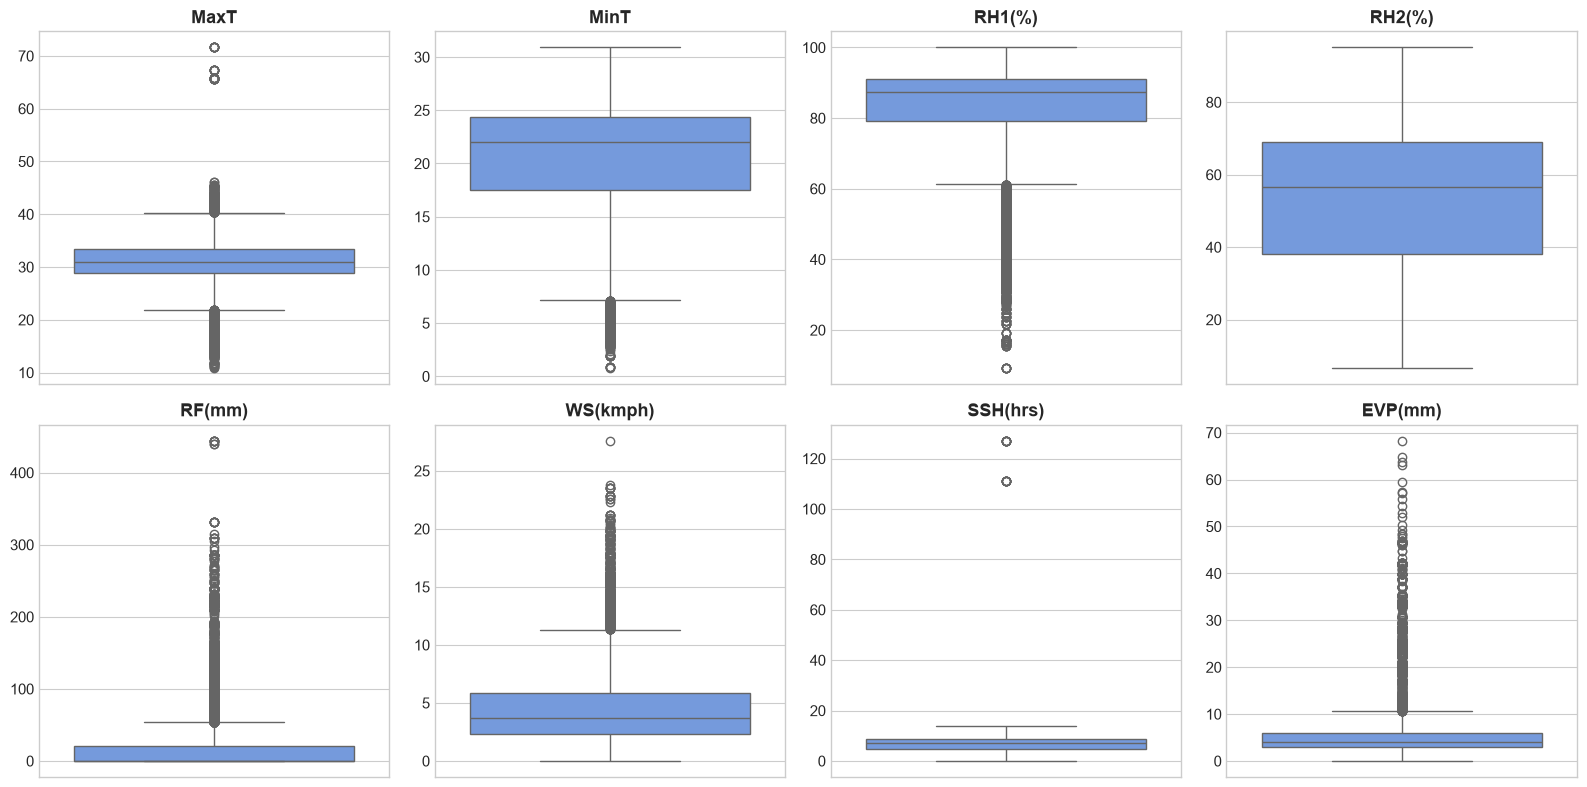

Saved boxplots to: ..\experiments\figures\05_weather_boxplots.png

=== Physical Plausibility & Domain Anomalies Audit ===
1. Impossible Maximum Temperatures (MaxT > 50°C): 32 records
   Example anomalous records (MaxT recorded as 65.6°C - 71.6°C in Maruteru 2011 — likely Fahrenheit):


,Observation Year,Standard Week,Location,MaxT,MinT
4299,2011,2,Maruteru,65.8,17.1
4302,2011,5,Maruteru,67.4,18.8
4328,2011,31,Maruteru,65.6,24.0
4335,2011,38,Maruteru,71.6,25.9



2. Anomalous Sunshine Hours (SSH > 15 hrs/day): 16 records
   Example anomalous records (SSH recorded as 111.0 and 127.1 in Maruteru 2011):


,Observation Year,Standard Week,Location,SSH(hrs)
4325,2011,28,Maruteru,127.1
4327,2011,30,Maruteru,111.0


In [11]:
outlier_records = []
for col in weather_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_records.append({
        'Feature': col,
        'Min': round(df[col].min(), 2),
        'Q1': round(q1, 2),
        'Median': round(df[col].median(), 2),
        'Q3': round(q3, 2),
        'Max': round(df[col].max(), 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier Pct (%)': round(len(outliers) / len(df) * 100, 2)
    })

display(pd.DataFrame(outlier_records))

# Boxplot visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(weather_features):
    sns.boxplot(y=df[col], ax=axes[i], color='cornflowerblue')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel("")

plt.tight_layout()
box_path = figures_dir / '05_weather_boxplots.png'
plt.savefig(box_path, dpi=200)
plt.show()
print(f"Saved boxplots to: {box_path}")

print("\n=== Physical Plausibility & Domain Anomalies Audit ===")
# 1. MaxT > 50°C (Meteorological impossibility in Indian rice agro-ecosystems)
temp_errors = df[df['MaxT'] > 50]
print(f"1. Impossible Maximum Temperatures (MaxT > 50°C): {len(temp_errors)} records")
if len(temp_errors) > 0:
    print("   Example anomalous records (MaxT recorded as 65.6°C - 71.6°C in Maruteru 2011 — likely Fahrenheit):")
    display(temp_errors[['Observation Year', 'Standard Week', 'Location', 'MaxT', 'MinT']].drop_duplicates().head(5))

# 2. SSH > 15 hours/day
ssh_errors = df[df['SSH(hrs)'] > 15]
print(f"\n2. Anomalous Sunshine Hours (SSH > 15 hrs/day): {len(ssh_errors)} records")
if len(ssh_errors) > 0:
    print("   Example anomalous records (SSH recorded as 111.0 and 127.1 in Maruteru 2011):")
    display(ssh_errors[['Observation Year', 'Standard Week', 'Location', 'SSH(hrs)']].drop_duplicates())


## SECTION 9 — Time / Location Investigation
Here we analyze the temporal and spatial span of the records to assess:
1. Temporal consistency across the 48-year period (1959–2011).
2. Seasonal coverage across Standard Meteorological Weeks (1–52).
3. Geographical representation across 6 research stations.
4. **Data Leakage Risks:** Temporal leakage (shuffling future data into train sets) and spatial leakage (memorizing station-specific weather instead of learning generalizable pest dynamics).


=== Station Temporal Coverage Summary ===


,Location,Start_Year,End_Year,Unique_Years,Total_Records
0,Cuttack,1959,2010,25,1456
1,Ludhiana,1995,2011,10,1976
2,Maruteru,1994,2011,18,7053
3,Palampur,1984,2004,21,1248
4,Raipur,1995,2009,12,2132
5,Rajendranagar,1975,2011,32,5539


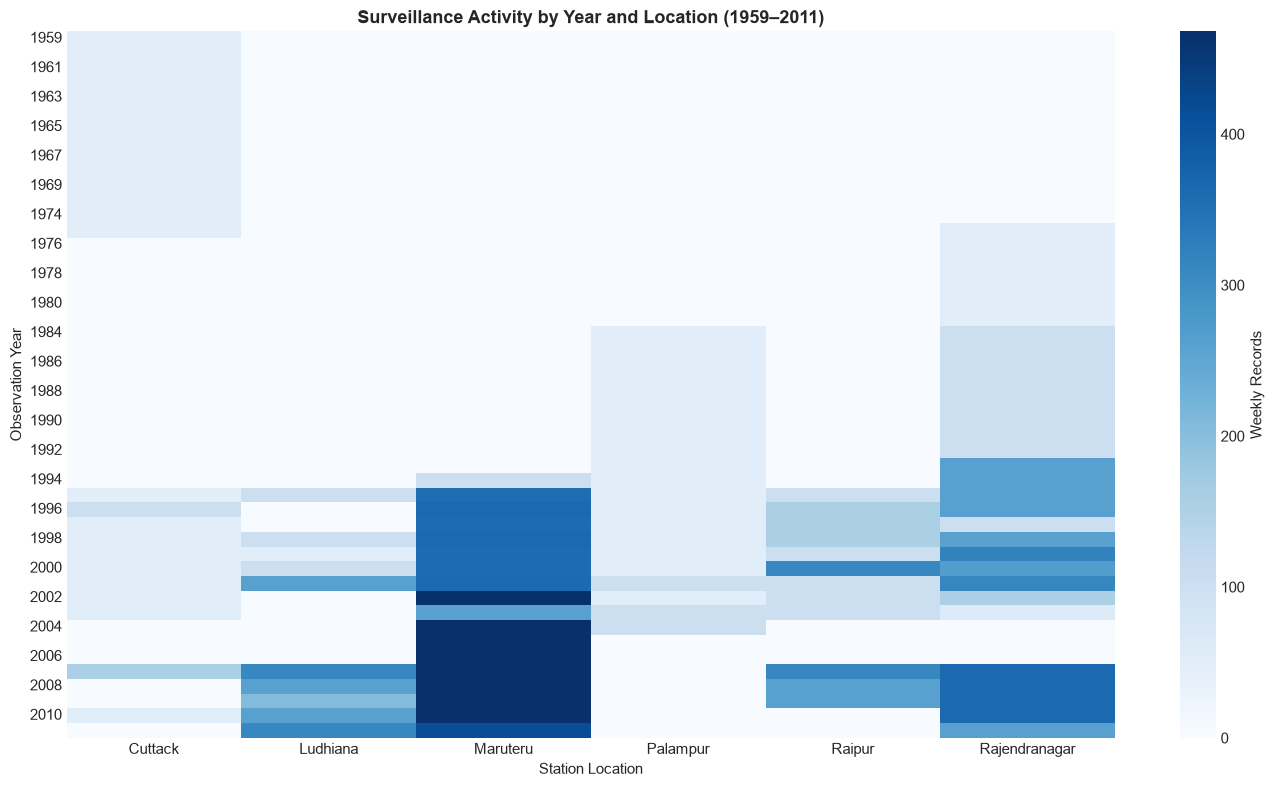

Saved temporal heatmap to: ..\experiments\figures\06_temporal_coverage.png
Standard Week distribution: min=369, max=375, mean=373.2


In [12]:
# 1. Temporal span across stations
station_timeline = df.groupby('Location').agg(
    Start_Year=('Observation Year', 'min'),
    End_Year=('Observation Year', 'max'),
    Unique_Years=('Observation Year', 'nunique'),
    Total_Records=('Observation Year', 'count')
).reset_index()

print("=== Station Temporal Coverage Summary ===")
display(station_timeline)

# 2. Year vs Location Cross-Tabulation
year_loc_ct = pd.crosstab(df['Observation Year'], df['Location'])

plt.figure(figsize=(14, 8))
sns.heatmap(year_loc_ct, cmap="Blues", cbar_kws={'label': 'Weekly Records'})
plt.title("Surveillance Activity by Year and Location (1959–2011)", fontweight='bold')
plt.xlabel("Station Location")
plt.ylabel("Observation Year")
plt.tight_layout()
temp_path = figures_dir / '06_temporal_coverage.png'
plt.savefig(temp_path, dpi=200)
plt.show()
print(f"Saved temporal heatmap to: {temp_path}")

# 3. Standard Meteorological Week (Seasonality)
week_counts = df['Standard Week'].value_counts().sort_index()
print(f"Standard Week distribution: min={week_counts.min()}, max={week_counts.max()}, mean={week_counts.mean():.1f}")


## SECTION 10 — ML Problem Definition
Based **strictly on the actual data contents and structure**, we evaluate possible formulations for Module 1:

### Problem Formulations Evaluated:

1. **Formulation A: Binary Pest/Disease Outbreak Risk (Classification) — RECOMMENDED**
   * **Task:** Predict whether an agro-meteorological condition creates active risk ($y = 1$ if $\text{Pest Value} > 0$ or above threshold, else $y = 0$).
   * **Target:** `Risk_Binary` (or pest-specific threshold).
   * **Feasibility:** Very High. The dataset has 19,404 records with 44.7% zeros and 55.3% positives, providing near-ideal class balance for binary classifiers.

2. **Formulation B: Species-Specific Multi-Level Risk Tiering (Ordinal Classification)**
   * **Task:** Predict risk tiers: `Low` (Zero/below economic threshold), `Moderate` (sub-economic alert), `High` (economic injury outbreak).
   * **Target:** Quantile-based or agronomic threshold tiers per pest species.
   * **Feasibility:** High. Directly translates into farmer advisories (Yellow/Orange/Red alerts).

3. **Formulation C: Specific Rice Blast Epidemic Forecasting (Disease Focus)**
   * **Task:** Predict `LeafBlast` severity percentage using temperature, humidity, and rainfall.
   * **Feasibility:** High. 2,090 records of `LeafBlast` at Maruteru and Rajendranagar show significant physical correlation with humidity ($r = +0.35$).

4. **Formulation D: Global Direct Count Regression — NOT RECOMMENDED**
   * **Task:** Predict continuous `Pest Value` across all pests using a single regressor.
   * **Feasibility:** Very Poor. Extremely invalid due to mixed units (percentages mixed with trap counts of 300,000).


In [13]:
print("=== Data Evidence for ML Formulations ===")
print("1. Binary balance (Presence vs Absence):")
print(f"   - Absence (Zeroes): {(df['Pest Value'] == 0).sum():,} ({(df['Pest Value'] == 0).mean()*100:.2f}%)")
print(f"   - Presence (Positives): {(df['Pest Value'] > 0).sum():,} ({(df['Pest Value'] > 0).mean()*100:.2f}%)")

print("\n2. Disease vs Insect Pest Breakdown:")
disease_rows = df[df['PEST NAME'].isin(['LeafBlast', 'NeckBlast'])]
pest_rows = df[~df['PEST NAME'].isin(['LeafBlast', 'NeckBlast'])]
print(f"   - Fungal Disease Records: {len(disease_rows):,} ({len(disease_rows)/len(df)*100:.2f}%)")
print(f"   - Insect Pest Records: {len(pest_rows):,} ({len(pest_rows)/len(df)*100:.2f}%)")

print("\n3. Multiclass Class Balance (PEST NAME as target):")
print(f"   - Number of Classes: {df['PEST NAME'].nunique()}")
print(f"   - Most frequent: {df['PEST NAME'].value_counts().index[0]} ({df['PEST NAME'].value_counts().iloc[0]:,} records)")
print(f"   - Least frequent: {df['PEST NAME'].value_counts().index[-1]} ({df['PEST NAME'].value_counts().iloc[-1]:,} records)")
print(f"   - Imbalance Ratio: {df['PEST NAME'].value_counts().iloc[0] / df['PEST NAME'].value_counts().iloc[-1]:.2f}:1")


=== Data Evidence for ML Formulations ===
1. Binary balance (Presence vs Absence):
   - Absence (Zeroes): 8,670 (44.68%)
   - Presence (Positives): 10,734 (55.32%)

2. Disease vs Insect Pest Breakdown:
   - Fungal Disease Records: 2,298 (11.84%)
   - Insect Pest Records: 17,106 (88.16%)

3. Multiclass Class Balance (PEST NAME as target):
   - Number of Classes: 11
   - Most frequent: Yellowstemborer (4,333 records)
   - Least frequent: NeckBlast (208 records)
   - Imbalance Ratio: 20.83:1


## SECTION 11 — Suitability Assessment

### DATASET STATUS: Potentially Suitable (with Specific Agricultural & Preprocessing Constraints)

---

### Strengths:
1. **Real-world Agro-Meteorological Foundation:** Sourced directly from premier Indian rice research stations (ICAR-CRRI Cuttack, PJTSAU Rajendranagar, IGKV Raipur, PAU Ludhiana, RARS Maruteru, CSKHPKV Palampur).
2. **Substantial Sample Size:** Contains **19,404 weekly surveillance records**, providing ample statistical power for training machine learning algorithms.
3. **Comprehensive Weather Features:** Features 8 key meteorological parameters (`MaxT`, `MinT`, `RH1`, `RH2`, `RF`, `WS`, `SSH`, `EVP`) known to govern insect pest emergence and fungal spore germination.
4. **Complete Records:** Zero explicit missing values (`null` or `NaN`) across all 19,404 rows and 14 columns.
5. **Clear Agro-Pathological Signal:** Shows clear, biologically sound correlation between relative humidity, minimum temperature, and `LeafBlast` severity.
6. **Near-Ideal Binary Class Balance:** 44.68% zero values (absence/negligible) vs. 55.32% positive values (active infestation).

---

### Weaknesses:
1. **Target Unit Heterogeneity:** `Pest Value` is not unified. It mixes light trap insect counts (up to 311,169), percentage leaf damage (0–87.2%), and insects per hill.
2. **Severe Positive Skewness:** Positive counts exhibit extreme right-skew (kurtosis > 1,000, max = 311,169), requiring logarithmic transformation or classification binning.
3. **Physical Data Entry Anomalies:** Certain years/stations exhibit recording errors, notably `MaxT > 65°C` (likely Fahrenheit entries) and `SSH > 100 hrs` in Maruteru (2011).
4. **Temporal Asymmetry:** Pre-1995 records are very sparse (52 records/year), whereas 1995–2011 records are dense (~1,000+ records/year).
5. **Predominance of Insect Pests over Fungal Diseases:** Out of 11 entities, 9 are insect pests (88.1% of data) and only 2 are fungal diseases (11.9% of data: Leaf Blast and Neck Blast). Major diseases such as Bacterial Leaf Blight and Sheath Blight are absent.

---

### Possible ML Task:
* **Primary Recommendation:** **Binary or Multi-class Infestation Risk Classification** per pest/disease species using agro-meteorological inputs.
* **Secondary Recommendation:** **Species-Segmented Severity Forecasting** (specifically for `LeafBlast` or `Yellowstemborer`).

---

### Potential Target:
* **Option A (Binary Risk):** `Risk_Level` ($0 = \text{Low/None}$, $1 = \text{Active Risk}$).
* **Option B (Ordinal Risk Alert):** `Low`, `Medium`, `High` risk tiers mapped to agronomic thresholds for decision support.
* **Option C (Disease Severity %):** `Pest Value` specifically for `LeafBlast`.

---

### Potential Features:
* **Meteorological Predictors:** `MaxT`, `MinT`, `RH1(%)`, `RH2(%)`, `RF(mm)`, `WS(kmph)`, `SSH(hrs)`, `EVP(mm)`.
* **Engineered Temporal Features:** `Standard Week` (cyclical sine/cosine encoding to capture seasonality), moving averages of weather (1–2 week lags).
* **Contextual Features:** `Location`, `PEST NAME` (for unified multi-species risk models).

---

### Important Limitations:
1. **No Soil or Crop Phenology Data:** The dataset lacks soil moisture, soil type, crop growth stage (e.g., tillering, panicle initiation), and rice variety resistance levels.
2. **Data Leakage Vulnerability:** Standard random $K$-fold cross-validation will cause severe data leakage because records from the same week share identical weather features. **Time-series rolling split or group split by year/station is mandatory.**
3. **Surveillance Discrepancies:** Trap catches reflect adult flying insect populations rather than larval field damage, necessitating cautious interpretation in farmer advisories.


In [14]:
print("=== INVESTIGATION SUMMARY METRICS ===")
print(f"Dataset: Rice - Pest and Diseases (Kaggle)")
print(f"Total Records: {len(df):,}")
print(f"Total Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Exact Duplicates: {df.duplicated().sum()}")
print(f"Pests & Diseases Tracked: {df['PEST NAME'].nunique()}")
print(f"Agricultural Stations: {df['Location'].nunique()}")
print(f"Year Span: {df['Observation Year'].min()} - {df['Observation Year'].max()}")
print(f"Status Recommendation: POTENTIALLY SUITABLE (Target segmentation & temporal splitting required)")


=== INVESTIGATION SUMMARY METRICS ===
Dataset: Rice - Pest and Diseases (Kaggle)
Total Records: 19,404
Total Columns: 15
Missing Values: 0
Exact Duplicates: 0
Pests & Diseases Tracked: 11
Agricultural Stations: 6
Year Span: 1959 - 2011
Status Recommendation: POTENTIALLY SUITABLE (Target segmentation & temporal splitting required)
